# EDA Dataset V02 - Smart Posture Monitor

Notebook nay phan tich truc tiep dataset baseline V02 hien tai tu `data/processed/features.csv`.

Muc tieu chinh:
- kiem tra chat luong bang feature sau `DatasetBuilder`;
- xac nhan metadata va 29 engineered features duoc tach dung;
- danh gia phan bo class, person, session;
- quan sat distribution, outlier, correlation, PCA va variation giua subject;
- khong tao preprocessing artifact, khong train model, khong loai sample trong EDA.


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

# Notebook nam trong notebooks/, nhung cell van chay on khi kernel cwd la project root hoac notebooks/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

METADATA_COLS = ["image_path", "session_id", "person_id", "label"]
EXPECTED_LABELS = ["correct", "forward_slouch", "lean_left", "lean_right"]
EXPECTED_FEATURE_COUNT = 29

print(f"Thu muc project: {PROJECT_ROOT}")
print(f"Duong dan dataset: {DATA_PATH}")
print(f"Dataset ton tai: {DATA_PATH.exists()}")


Thu muc project: G:\PTIT TL\K1N3\PYTHON\BTL\smart_posture_monitor
Duong dan dataset: G:\PTIT TL\K1N3\PYTHON\BTL\smart_posture_monitor\data\processed\features.csv
Dataset ton tai: True


## 1. Doc dataset

Dataset source duy nhat cua notebook la `data/processed/features.csv`. Notebook khong su dung file `_v02`, file cu, hoac absolute path theo may ca nhan.


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay dataset: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Kich thuoc dataframe: {df.shape[0]} dong x {df.shape[1]} cot")
print("5 dong dau tien:")
print(df.head().to_string(index=False))


Kich thuoc dataframe: 4014 dong x 33 cot
5 dong dau tien:
                                                                                         image_path session_id person_id   label  shoulder_angle  eye_shoulder_angle  eye_vertical_difference  nose_x_body  nose_y_body  eye_center_x_body  eye_center_y_body  left_ear_x_body  left_ear_y_body  nose_eye_dx  nose_eye_dy  eye_width_ratio  ear_eye_ratio  nose_shoulder_center_distance  eye_shoulder_center_distance  nose_shoulder_asymmetry  eye_shoulder_asymmetry  nose_ear_ratio  head_body_angle  head_gravity_angle  nose_gravity_angle  face_pitch_angle  eye_vertical_axis_offset  nose_vertical_axis_offset  head_mean_height  head_height_spread  nose_body_angle  ear_body_angle  head_axis_angle_spread
G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monitor/data/raw/correct/person01_session01/frame_0001.jpg  session01  person01 correct        2.769472          -13.635900                -0.054078     0.404426     0.729530           0.350021           0.

## 2. Kiem tra schema va chat luong du lieu

Phan nay xac nhan metadata khong bi dua nham vao feature numeric. `feature_cols` duoc xac dinh bang cach loai dung 4 metadata columns.


In [4]:
missing_metadata = [c for c in METADATA_COLS if c not in df.columns]
if missing_metadata:
    raise ValueError(f"Thieu metadata columns: {missing_metadata}")

feature_cols = [c for c in df.columns if c not in METADATA_COLS]
feature_df = df[feature_cols].apply(pd.to_numeric, errors="coerce")

validation = {
    "so_dong": len(df),
    "so_cot": len(df.columns),
    "so_cot_metadata": len(METADATA_COLS),
    "so_cot_feature": len(feature_cols),
    "dong_trung_lap": int(df.duplicated().sum()),
    "tong_missing_values": int(df.isna().sum().sum()),
    "tong_nan_trong_feature": int(feature_df.isna().sum().sum()),
    "tong_inf_trong_feature": int(np.isinf(feature_df.to_numpy(dtype=float)).sum()),
    "so_label_duy_nhat": df["label"].nunique(),
    "so_person_duy_nhat": df["person_id"].nunique(),
    "so_session_id_duy_nhat": df["session_id"].nunique(),
    "so_person_session_duy_nhat": (df["person_id"].astype(str) + "_" + df["session_id"].astype(str)).nunique(),
}

print("Tong quan validation:")
print(pd.Series(validation).to_string())
print("\nDanh sach cot:")
print(df.columns.to_list())
print("\nDanh sach 29 feature columns:")
print(feature_cols)
print("\nKieu du lieu cua feature columns:")
print(feature_df.dtypes.value_counts().to_string())

if len(feature_cols) != EXPECTED_FEATURE_COUNT:
    raise ValueError(f"Can {EXPECTED_FEATURE_COUNT} features, nhung dang co {len(feature_cols)}")
if sorted(df["label"].unique()) != sorted(EXPECTED_LABELS):
    raise ValueError(f"Label khong dung ky vong: {sorted(df['label'].unique())}")
if validation["tong_nan_trong_feature"] != 0 or validation["tong_inf_trong_feature"] != 0:
    raise ValueError("Feature matrix co NaN hoac Inf")


Tong quan validation:
so_dong                       4014
so_cot                          33
so_cot_metadata                  4
so_cot_feature                  29
dong_trung_lap                   0
tong_missing_values              0
tong_nan_trong_feature           0
tong_inf_trong_feature           0
so_label_duy_nhat                4
so_person_duy_nhat              14
so_session_id_duy_nhat           3
so_person_session_duy_nhat      16

Danh sach cot:
['image_path', 'session_id', 'person_id', 'label', 'shoulder_angle', 'eye_shoulder_angle', 'eye_vertical_difference', 'nose_x_body', 'nose_y_body', 'eye_center_x_body', 'eye_center_y_body', 'left_ear_x_body', 'left_ear_y_body', 'nose_eye_dx', 'nose_eye_dy', 'eye_width_ratio', 'ear_eye_ratio', 'nose_shoulder_center_distance', 'eye_shoulder_center_distance', 'nose_shoulder_asymmetry', 'eye_shoulder_asymmetry', 'nose_ear_ratio', 'head_body_angle', 'head_gravity_angle', 'nose_gravity_angle', 'face_pitch_angle', 'eye_vertical_axis_offset', '

**Nhan xet validation.** Dataset hien co `4014` rows, `29` engineered features va 4 metadata columns. Khong phat hien duplicate rows (`0`), missing values (`0`), NaN trong feature matrix (`0`), hoac Inf (`0`). Metadata duoc tach khoi feature columns truoc moi phan tich numeric/PCA.


## 3. Phan bo label

EDA kiem tra du 4 posture labels va danh gia class imbalance dua tren count/percentage thuc te.


So mau hop le theo tung label:
                so_mau  ty_le_phan_tram
label                                  
correct           1051            26.18
forward_slouch     889            22.15
lean_left         1054            26.26
lean_right        1020            25.41


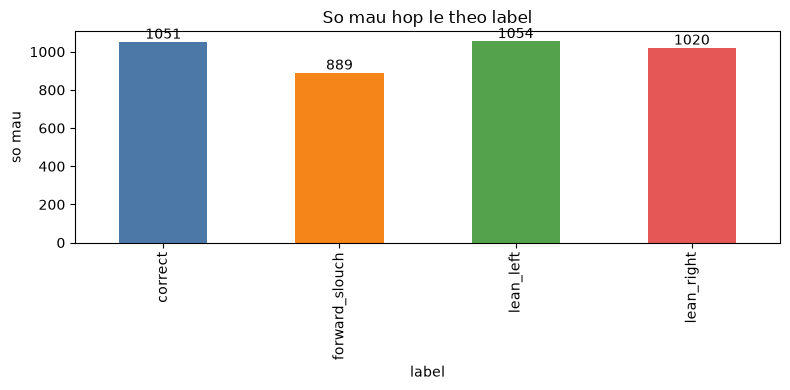

In [5]:
label_summary = df["label"].value_counts().reindex(EXPECTED_LABELS).fillna(0).astype(int).rename("so_mau").to_frame()
label_summary["ty_le_phan_tram"] = label_summary["so_mau"] / len(df) * 100
print("So mau hop le theo tung label:")
print(label_summary.to_string(float_format=lambda x: f"{x:.2f}"))

ax = label_summary["so_mau"].plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
ax.set_title("So mau hop le theo label")
ax.set_xlabel("label")
ax.set_ylabel("so mau")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


**Nhan xet label.** Dataset co 4 labels dung ky vong. Class nho nhat la `forward_slouch` voi `889` samples, class lon nhat la `lean_left` voi `1054` samples; ty le max/min khoang `1.19x`, nen class distribution tuong doi can bang. `forward_slouch` thap hon cac class con lai nhung khong phai mat can bang cuc doan.


## 4. Phan bo theo person

Phan nay phan biet sample imbalance giua person voi class imbalance. `person05` la du lieu moi hop le va duoc phan tich nhu moi person khac.


So mau hop le theo tung person:
           so_mau  ty_le_phan_tram
person_id                         
person01      148             3.69
person02      277             6.90
person03      201             5.01
person04      275             6.85
person05      260             6.48
person06      240             5.98
person07      796            19.83
person08      226             5.63
person09      273             6.80
person10      307             7.65
person11      258             6.43
person12      252             6.28
person13      255             6.35
person14      246             6.13


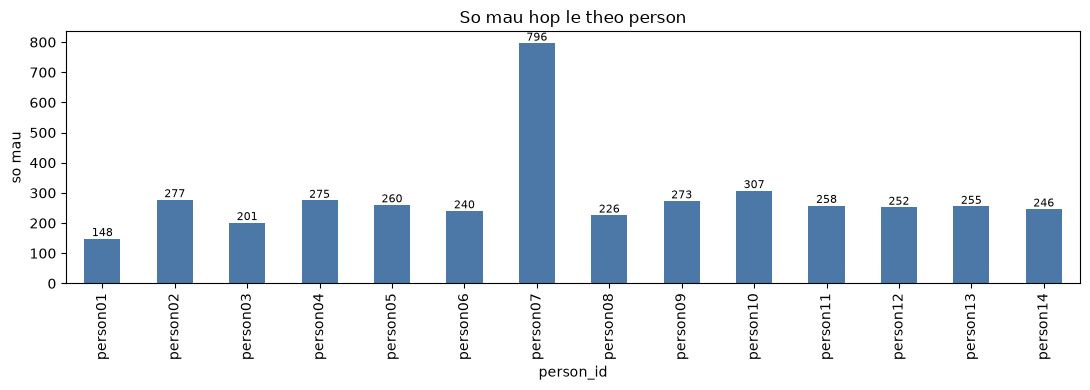

In [6]:
person_summary = df["person_id"].value_counts().sort_index().rename("so_mau").to_frame()
person_summary["ty_le_phan_tram"] = person_summary["so_mau"] / len(df) * 100
print("So mau hop le theo tung person:")
print(person_summary.to_string(float_format=lambda x: f"{x:.2f}"))

ax = person_summary["so_mau"].plot(kind="bar", figsize=(11, 4), color="#4C78A8")
ax.set_title("So mau hop le theo person")
ax.set_xlabel("person_id")
ax.set_ylabel("so mau")
ax.bar_label(ax.containers[0], fontsize=8)
plt.tight_layout()
plt.show()


**Nhan xet person.** Dataset hien co `14` persons. Sample distribution giua person khong deu: thap nhat la `person01` voi `148` samples, cao nhat la `person07` voi `796` samples. `person07` noi bat vi co nhieu session, khong phai vi class imbalance. `person05` khong con bi coi la subject loi va khong bi loai khoi EDA.


## 5. Phan bo theo session

`session_id` rieng le co the lap lai giua nhieu person, vi vay notebook tao `session_key = person_id + '_' + session_id` de kiem tra session duy nhat theo subject.


So mau theo tung person-session:
       session_key person_id session_id  so_mau
person01_session01  person01  session01     148
person02_session01  person02  session01     277
person03_session01  person03  session01     201
person04_session01  person04  session01     275
person05_session01  person05  session01     260
person06_session01  person06  session01     240
person07_session01  person07  session01     297
person07_session02  person07  session02     258
person07_session03  person07  session03     241
person08_session01  person08  session01     226
person09_session01  person09  session01     273
person10_session01  person10  session01     307
person11_session01  person11  session01     258
person12_session01  person12  session01     252
person13_session01  person13  session01     255
person14_session01  person14  session01     246

So session theo tung person:
person_id
person01    1
person02    1
person03    1
person04    1
person05    1
person06    1
person07    3
person08    1

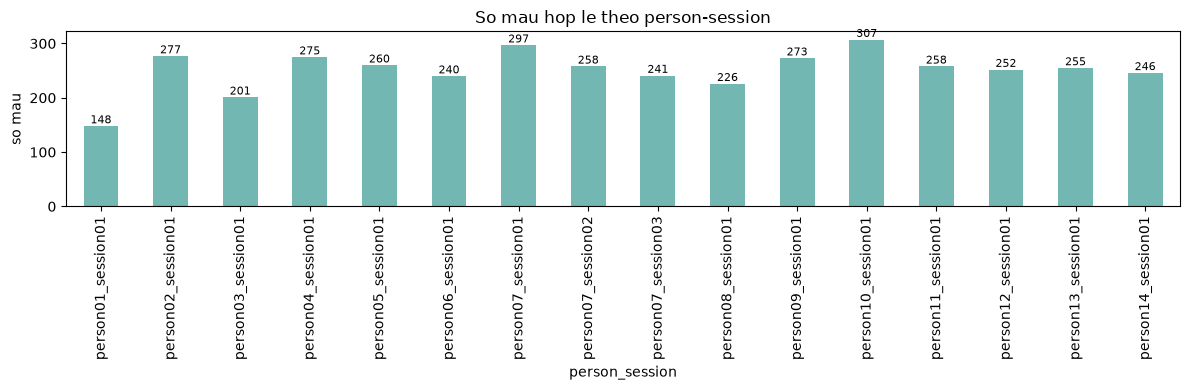

In [7]:
df = df.copy()
df["session_key"] = df["person_id"].astype(str) + "_" + df["session_id"].astype(str)
session_summary = df.groupby(["person_id", "session_id"]).size().rename("so_mau").reset_index()
session_summary["session_key"] = session_summary["person_id"] + "_" + session_summary["session_id"]
session_summary = session_summary[["session_key", "person_id", "session_id", "so_mau"]]
print("So mau theo tung person-session:")
print(session_summary.to_string(index=False))

sessions_per_person = session_summary.groupby("person_id")["session_id"].nunique().rename("so_session")
print("\nSo session theo tung person:")
print(sessions_per_person.to_string())

ax = session_summary.set_index("session_key")["so_mau"].plot(kind="bar", figsize=(12, 4), color="#72B7B2")
ax.set_title("So mau hop le theo person-session")
ax.set_xlabel("person_session")
ax.set_ylabel("so mau")
ax.bar_label(ax.containers[0], fontsize=8)
plt.tight_layout()
plt.show()


**Nhan xet session.** Dataset co `16` person-session combinations. `session_id` co `3` gia tri duy nhat (`session01, session02, session03`), nhung khi gan voi `person_id` thi co `16` sessions thuc te. `person07` co 3 sessions; cac person con lai co 1 session theo du lieu hien tai. Session metadata parse dung va khong thay session key bat thuong.


## 6. Label theo person va session

Bang cheo giup kiem tra moi person/session dong gop ra sao cho tung class. Day la kiem tra sample coverage, khong phai danh gia model performance.


So mau label theo person:
label      correct  forward_slouch  lean_left  lean_right  tong
person_id                                                      
person01        49              11         57          31   148
person02        79              60         77          61   277
person03        57              37         64          43   201
person04        63              63         66          83   275
person05        73              63         61          63   260
person06        67              73         35          65   240
person07       211             192        201         192   796
person08        67              17         72          70   226
person09        84              65         57          67   273
person10        62              54        105          86   307
person11        57              63         72          66   258
person12        61              67         64          60   252
person13        60              63         67          65   255
person14      

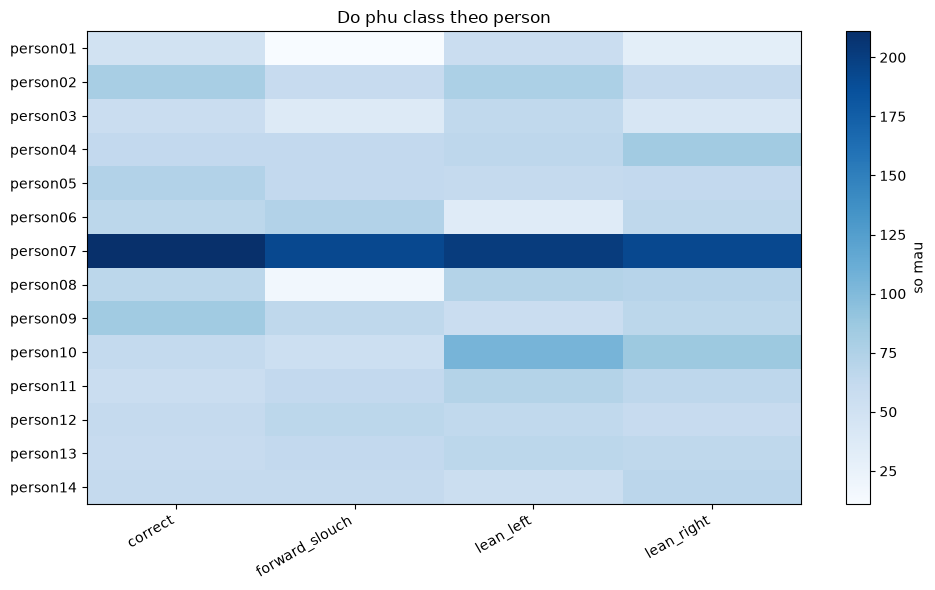

In [8]:
person_label = pd.crosstab(df["person_id"], df["label"]).reindex(columns=EXPECTED_LABELS, fill_value=0)
person_label["tong"] = person_label.sum(axis=1)
print("So mau label theo person:")
print(person_label.to_string())

session_label = pd.crosstab(df["session_key"], df["label"]).reindex(columns=EXPECTED_LABELS, fill_value=0)
session_label["tong"] = session_label.sum(axis=1)
print("\nSo mau label theo person-session:")
print(session_label.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(person_label[EXPECTED_LABELS].to_numpy(), aspect="auto", cmap="Blues")
ax.set_xticks(range(len(EXPECTED_LABELS)), EXPECTED_LABELS, rotation=30, ha="right")
ax.set_yticks(range(len(person_label.index)), person_label.index)
ax.set_title("Do phu class theo person")
fig.colorbar(im, ax=ax, label="so mau")
plt.tight_layout()
plt.show()


**Nhan xet coverage.** Moi person deu co samples o ca 4 labels trong dataset hien tai. Cac chenh lech theo person/session nen duoc xem la van de phan bo subject/session, tach biet voi phan bo class toan dataset.


## 7. Thong ke mo ta va variance cua feature

Cac thong ke ben duoi chi dung 29 feature columns, khong bao gom `image_path`, `session_id`, `person_id`, `label`, hoac `session_key`.


Thong ke mo ta cho 29 features:
                                  count     mean     std      min      25%      50%      75%     max
shoulder_angle                4014.0000   1.2604  9.1478 -33.7816  -1.6490   1.3896   6.3192 28.9115
eye_shoulder_angle            4014.0000  -7.1235  8.4813 -38.1837 -12.8419  -7.4652  -1.9452 26.7479
eye_vertical_difference       4014.0000  -0.0240  0.0309  -0.4564  -0.0430  -0.0263  -0.0068  0.1124
nose_x_body                   4014.0000   0.3640  0.2088  -0.1922   0.2433   0.3678   0.4799  4.5223
nose_y_body                   4014.0000   0.5226  0.1996  -0.0622   0.4143   0.5397   0.6499  1.6414
eye_center_x_body             4014.0000   0.3334  0.2006  -0.2113   0.2227   0.3284   0.4524  4.5319
eye_center_y_body             4014.0000   0.6478  0.1908   0.0695   0.5498   0.6566   0.7593  1.8774
left_ear_x_body               4014.0000  -0.0988  0.1234  -0.6684  -0.1715  -0.1022  -0.0323  2.0383
left_ear_y_body               4014.0000   0.6448  0.1251   

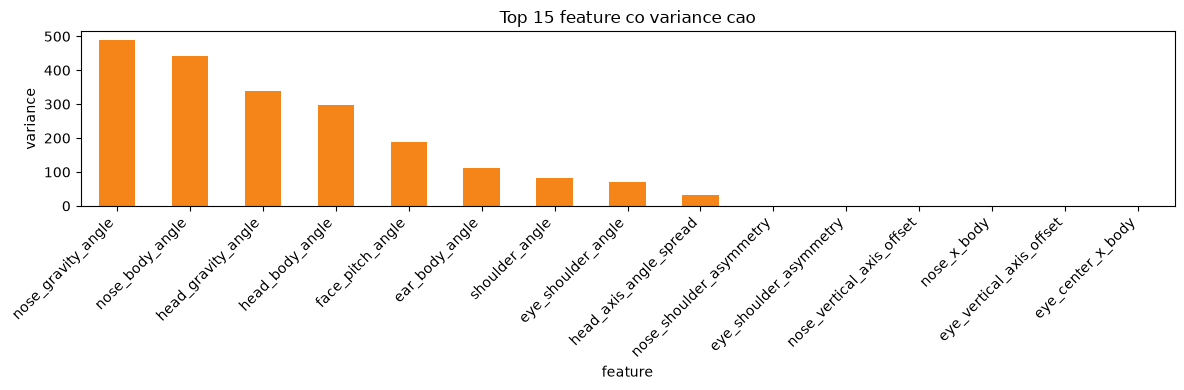

In [9]:
descriptive = feature_df.describe().T
variance_summary = feature_df.var().sort_values(ascending=False).rename("variance").to_frame()
print("Thong ke mo ta cho 29 features:")
print(descriptive.to_string(float_format=lambda x: f"{x:.4f}"))
print("\nTop 10 features co variance cao nhat:")
print(variance_summary.head(10).to_string(float_format=lambda x: f"{x:.6f}"))

ax = variance_summary.head(15)["variance"].plot(kind="bar", figsize=(12, 4), color="#F58518")
ax.set_title("Top 15 feature co variance cao")
ax.set_xlabel("feature")
ax.set_ylabel("variance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Nhan xet feature variance.** Feature variance khong dong deu. Khi xet khac biet mean giua person, cac feature co spread lon nhat gom `nose_body_angle, nose_gravity_angle, head_body_angle`. Dieu nay cho thay can chu y variation theo subject. EDA chua loai/cap feature nao; moi xu ly chuan hoa hoac robust scaling nen nam trong preprocessing/training pipeline sau nay.


## 8. Phan bo feature theo class

Hien thi histogram mot so feature co variance cao de quan sat phan bo va khac biet theo class. Cac khac biet nay la tin hieu EDA, khong phai cam ket model performance.


Cac feature variance cao duoc chon de ve phan bo:
['nose_gravity_angle', 'nose_body_angle', 'head_gravity_angle', 'head_body_angle', 'face_pitch_angle', 'ear_body_angle']


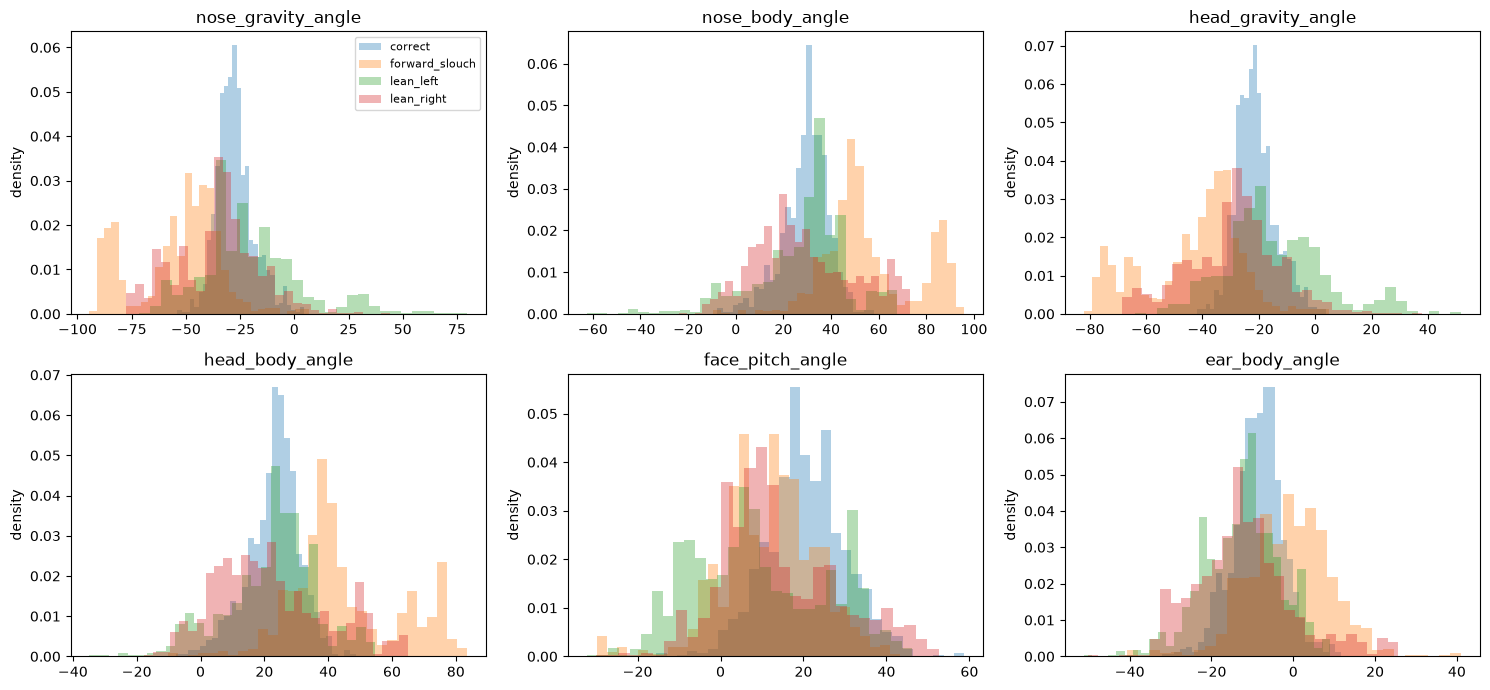

In [10]:
selected_features = variance_summary.head(6).index.to_list()
print("Cac feature variance cao duoc chon de ve phan bo:")
print(selected_features)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
for ax, feature in zip(axes, selected_features):
    for label in EXPECTED_LABELS:
        values = df.loc[df["label"] == label, feature]
        ax.hist(values, bins=30, alpha=0.35, density=True, label=label)
    ax.set_title(feature)
    ax.set_ylabel("density")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Nhan xet distribution theo class.** Mot so feature co phan bo khac nhau giua cac posture class, cho thay kha nang cung cap tin hieu phan biet nhat dinh tren dataset hien tai. Tuy nhien EDA chi quan sat phan bo; hieu qua phan loai can duoc kiem chung bang training/evaluation voi split phu hop theo `person_id`.


## 9. Boxplot va outlier analysis

Outlier duoc phat hien bang quy tac IQR 1.5x tren tung feature. Notebook chi thong ke va truc quan hoa, khong xoa sample.


So dong co it nhat 1 feature outlier theo IQR: 1071 / 4014
Top 15 features theo so luong outlier IQR:
shoulder_angle               414
head_gravity_angle           342
head_axis_angle_spread       340
nose_gravity_angle           310
eye_center_y_body            237
head_mean_height             229
nose_body_angle              223
nose_y_body                  193
head_body_angle              186
head_height_spread           140
ear_body_angle               119
left_ear_y_body              118
eye_vertical_axis_offset     112
nose_vertical_axis_offset    111
eye_vertical_difference      107

Tom tat outlier theo person:
           outlier_trung_binh  dong_co_outlier  tong_dong  ty_le_dong_co_outlier
person_id                                                                       
person06                 3.52              166        240                  69.17
person11                 1.90              140        258                  54.26
person03                 1.83              104   

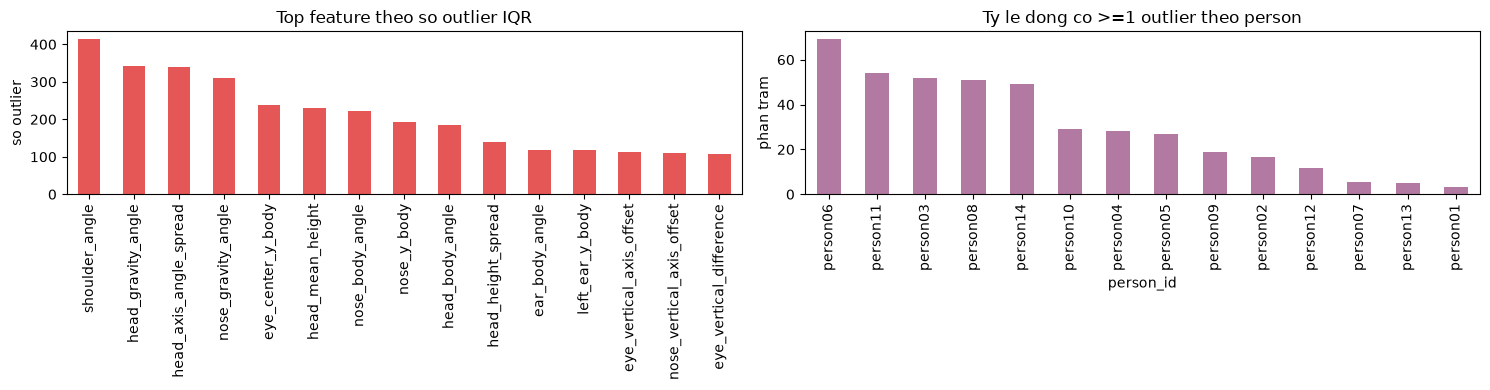

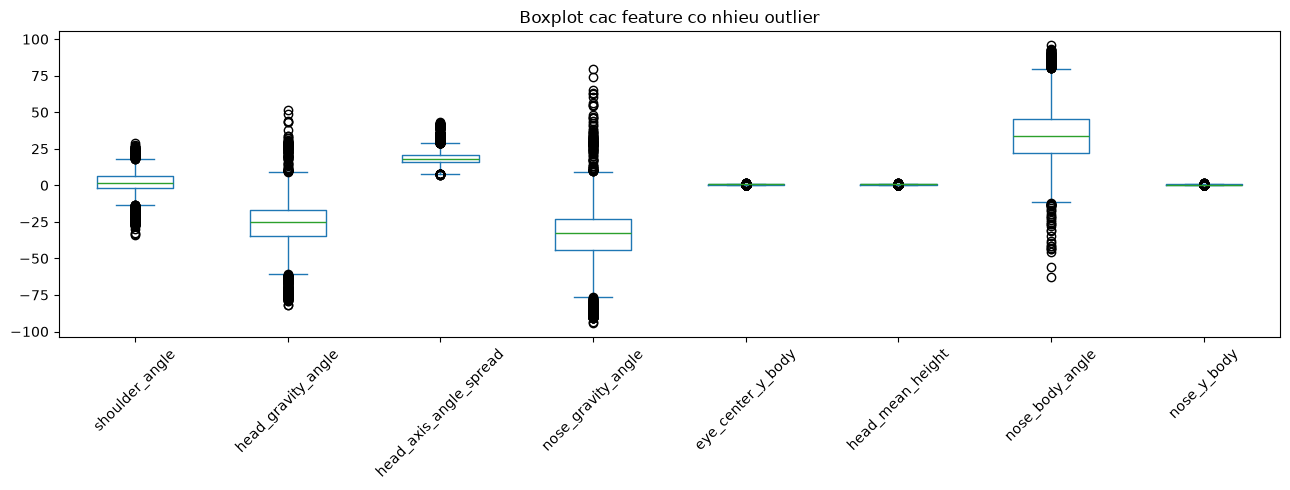

In [11]:
q1 = feature_df.quantile(0.25)
q3 = feature_df.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = (feature_df < lower) | (feature_df > upper)
outlier_by_feature = outlier_mask.sum().sort_values(ascending=False)
outlier_by_row = outlier_mask.sum(axis=1)

print(f"So dong co it nhat 1 feature outlier theo IQR: {(outlier_by_row > 0).sum()} / {len(df)}")
print("Top 15 features theo so luong outlier IQR:")
print(outlier_by_feature.head(15).to_string())

person_outliers = (
    pd.DataFrame({"person_id": df["person_id"], "so_feature_outlier": outlier_by_row})
    .groupby("person_id")
    .agg(outlier_trung_binh=("so_feature_outlier", "mean"), dong_co_outlier=("so_feature_outlier", lambda s: int((s > 0).sum())), tong_dong=("so_feature_outlier", "size"))
)
person_outliers["ty_le_dong_co_outlier"] = person_outliers["dong_co_outlier"] / person_outliers["tong_dong"] * 100
print("\nTom tat outlier theo person:")
print(person_outliers.sort_values("ty_le_dong_co_outlier", ascending=False).to_string(float_format=lambda x: f"{x:.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
outlier_by_feature.head(15).plot(kind="bar", ax=axes[0], color="#E45756")
axes[0].set_title("Top feature theo so outlier IQR")
axes[0].set_ylabel("so outlier")
person_outliers["ty_le_dong_co_outlier"].sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="#B279A2")
axes[1].set_title("Ty le dong co >=1 outlier theo person")
axes[1].set_ylabel("phan tram")
plt.tight_layout()
plt.show()

box_features = outlier_by_feature.head(8).index.to_list()
feature_df[box_features].plot(kind="box", figsize=(13, 5), rot=45)
plt.title("Boxplot cac feature co nhieu outlier")
plt.tight_layout()
plt.show()


**Nhan xet outlier.** Theo IQR, `1071` / `4014` rows co it nhat mot feature nam ngoai nguong. Feature co nhieu outlier nhat la `shoulder_angle` voi `414` rows. Day la tin hieu can preprocessing xem xet bang scaling/robust handling sau nay, nhung notebook khong loai hoac chinh outlier.


## 10. Correlation analysis

Correlation matrix duoc tinh tren 29 feature columns. Cac pair co absolute correlation cao co the goi y redundancy, nhung quyet dinh feature selection can dua tren evaluation sau nay.


Top 20 cap feature co absolute correlation cao nhat:
                    feature_a                    feature_b  abs_corr    corr
            eye_center_y_body             head_mean_height    0.9931  0.9931
           head_gravity_angle           nose_gravity_angle    0.9925  0.9925
              head_body_angle              nose_body_angle    0.9920  0.9920
      nose_shoulder_asymmetry       eye_shoulder_asymmetry    0.9917  0.9917
     eye_vertical_axis_offset    nose_vertical_axis_offset    0.9905  0.9905
                  nose_y_body            eye_center_y_body    0.9905  0.9905
                  nose_x_body            eye_center_x_body    0.9903  0.9903
nose_shoulder_center_distance eye_shoulder_center_distance    0.9891  0.9891
       eye_shoulder_asymmetry              head_body_angle    0.9876  0.9876
                ear_eye_ratio               nose_ear_ratio    0.9794  0.9794
       eye_shoulder_asymmetry              nose_body_angle    0.9793  0.9793
                  nose_

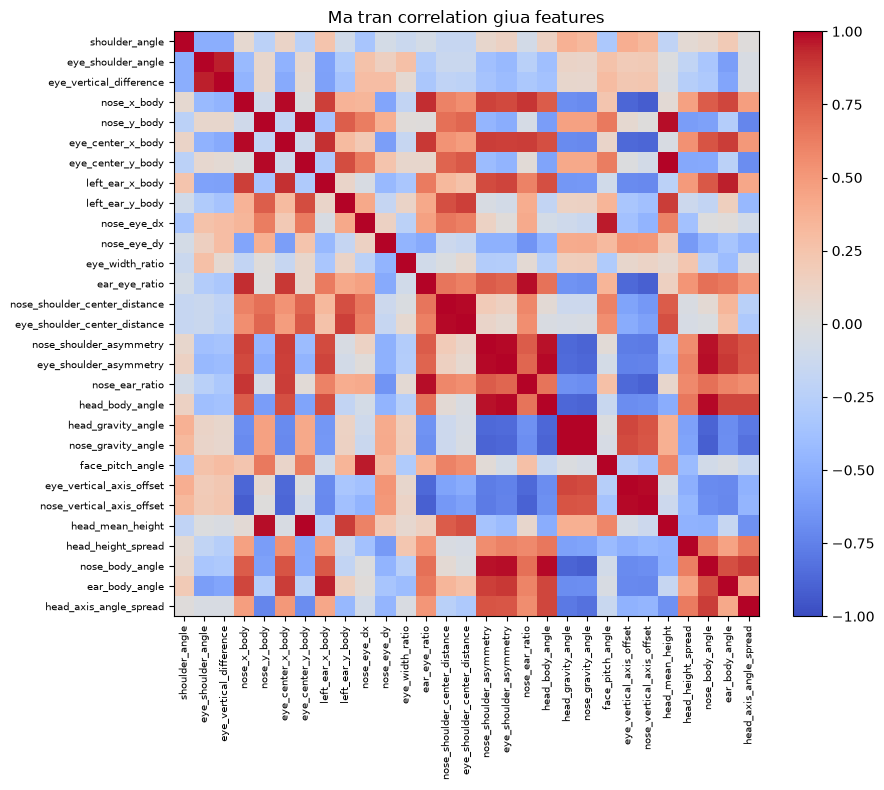

In [12]:
corr = feature_df.corr()
abs_corr = corr.abs()
pairs = []
for i, feature_a in enumerate(feature_cols):
    for feature_b in feature_cols[i + 1:]:
        pairs.append((feature_a, feature_b, abs_corr.loc[feature_a, feature_b], corr.loc[feature_a, feature_b]))
high_corr_pairs = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "abs_corr", "corr"]).sort_values("abs_corr", ascending=False)
print("Top 20 cap feature co absolute correlation cao nhat:")
print(high_corr_pairs.head(20).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nSo cap co abs_corr >= 0.90: {(high_corr_pairs['abs_corr'] >= 0.90).sum()}")
print(f"So cap co abs_corr >= 0.80: {(high_corr_pairs['abs_corr'] >= 0.80).sum()}")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)), feature_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(feature_cols)), feature_cols, fontsize=7)
ax.set_title("Ma tran correlation giua features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**Nhan xet correlation.** Pair co absolute correlation cao nhat la `eye_center_y_body` va `head_mean_height` voi `abs_corr=0.993`. Co `22` pairs >= 0.90 va `63` pairs >= 0.80, cho thay mot so feature co the chua thong tin trung lap. Day la quan sat EDA; chua thuc hien feature removal trong notebook.


## 11. PCA tren 29 scaled features

PCA duoc thuc hien bang SVD tren feature matrix da chuan hoa z-score trong notebook. Khong luu scaler/PCA artifact va khong dua metadata vao PCA.


Bang explained variance cua PCA (15 components dau):
component  explained_variance_pct  cumulative_variance_pct
      PC1                   46.80                    46.80
      PC2                   25.79                    72.59
      PC3                   10.93                    83.53
      PC4                    7.35                    90.88
      PC5                    3.22                    94.10
      PC6                    1.80                    95.90
      PC7                    1.35                    97.25
      PC8                    1.06                    98.31
      PC9                    0.82                    99.13
     PC10                    0.36                    99.49
     PC11                    0.16                    99.65
     PC12                    0.13                    99.78
     PC13                    0.07                    99.85
     PC14                    0.05                    99.90
     PC15                    0.03                    99.93

So

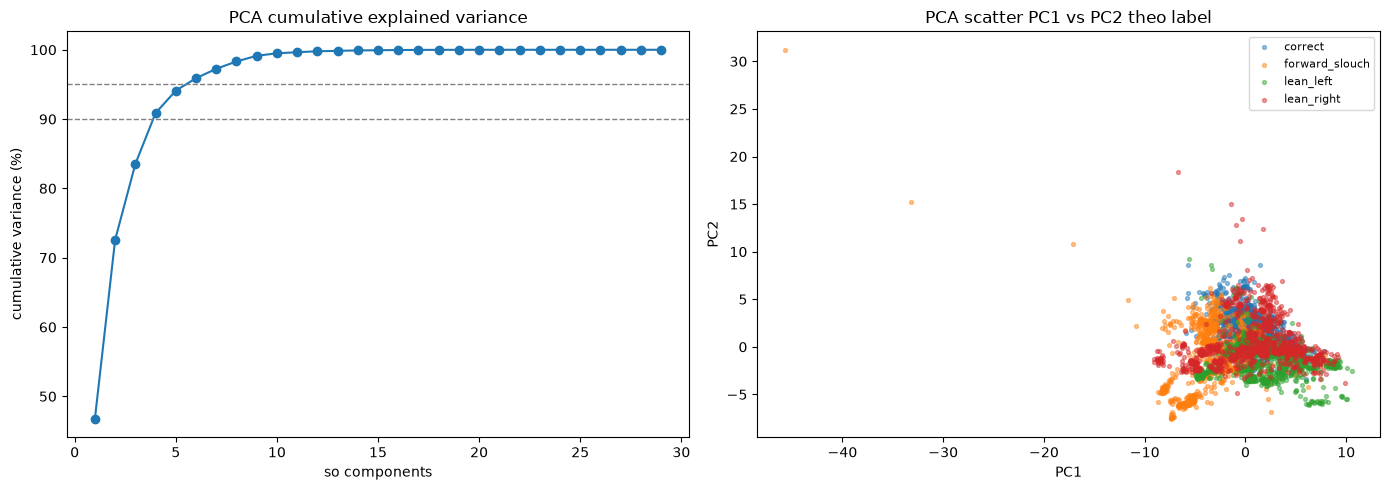

In [13]:
X = feature_df.to_numpy(dtype=float)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
if np.any(X_std == 0):
    raise ValueError("Co it nhat mot feature co standard deviation bang 0")
X_scaled = (X - X_mean) / X_std

U, s, vt = np.linalg.svd(X_scaled, full_matrices=False)
explained = (s ** 2) / (len(X_scaled) - 1)
explained_variance_pct = explained / explained.sum() * 100
cumulative_variance_pct = np.cumsum(explained_variance_pct)
components_90 = int(np.searchsorted(cumulative_variance_pct, 90) + 1)
components_95 = int(np.searchsorted(cumulative_variance_pct, 95) + 1)

pca_summary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(explained_variance_pct))],
    "explained_variance_pct": explained_variance_pct,
    "cumulative_variance_pct": cumulative_variance_pct,
})
print("Bang explained variance cua PCA (15 components dau):")
print(pca_summary.head(15).to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print(f"\nSo components de dat >=90% variance: {components_90}")
print(f"So components de dat >=95% variance: {components_95}")

scores = X_scaled @ vt.T
pca_plot_df = pd.DataFrame({"PC1": scores[:, 0], "PC2": scores[:, 1], "label": df["label"], "person_id": df["person_id"]})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(explained_variance_pct) + 1), cumulative_variance_pct, marker="o")
axes[0].axhline(90, color="gray", linestyle="--", linewidth=1)
axes[0].axhline(95, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("PCA cumulative explained variance")
axes[0].set_xlabel("so components")
axes[0].set_ylabel("cumulative variance (%)")

for label in EXPECTED_LABELS:
    sub = pca_plot_df[pca_plot_df["label"] == label]
    axes[1].scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.45, label=label)
axes[1].set_title("PCA scatter PC1 vs PC2 theo label")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Nhan xet PCA.** PC1 giai thich `46.80%` variance va PC2 giai thich `25.79%`. Can `4` components de dat >=90% variance va `6` components de dat >=95% variance. Dieu nay goi y feature space 29 chieu co mot phan redundancy/correlation, nhung khong the ket luan hieu nang model chi tu PCA.


## 12. Tin hieu phan biet class

Phan nay so sanh mean feature theo class va truc quan hoa mot so feature co khac biet mean lon. Day la quan sat EDA, khong phai ket luan model chac chan phan loai tot.


Top 12 features theo do chenh mean giua cac class:
nose_gravity_angle          33.8722
head_gravity_angle          28.6616
nose_body_angle             27.9818
head_body_angle             23.0149
shoulder_angle              14.4633
ear_body_angle              11.7181
face_pitch_angle            11.3929
head_axis_angle_spread       8.0314
eye_shoulder_angle           6.7375
nose_shoulder_asymmetry      0.3361
nose_vertical_axis_offset    0.3065
eye_vertical_axis_offset     0.3048


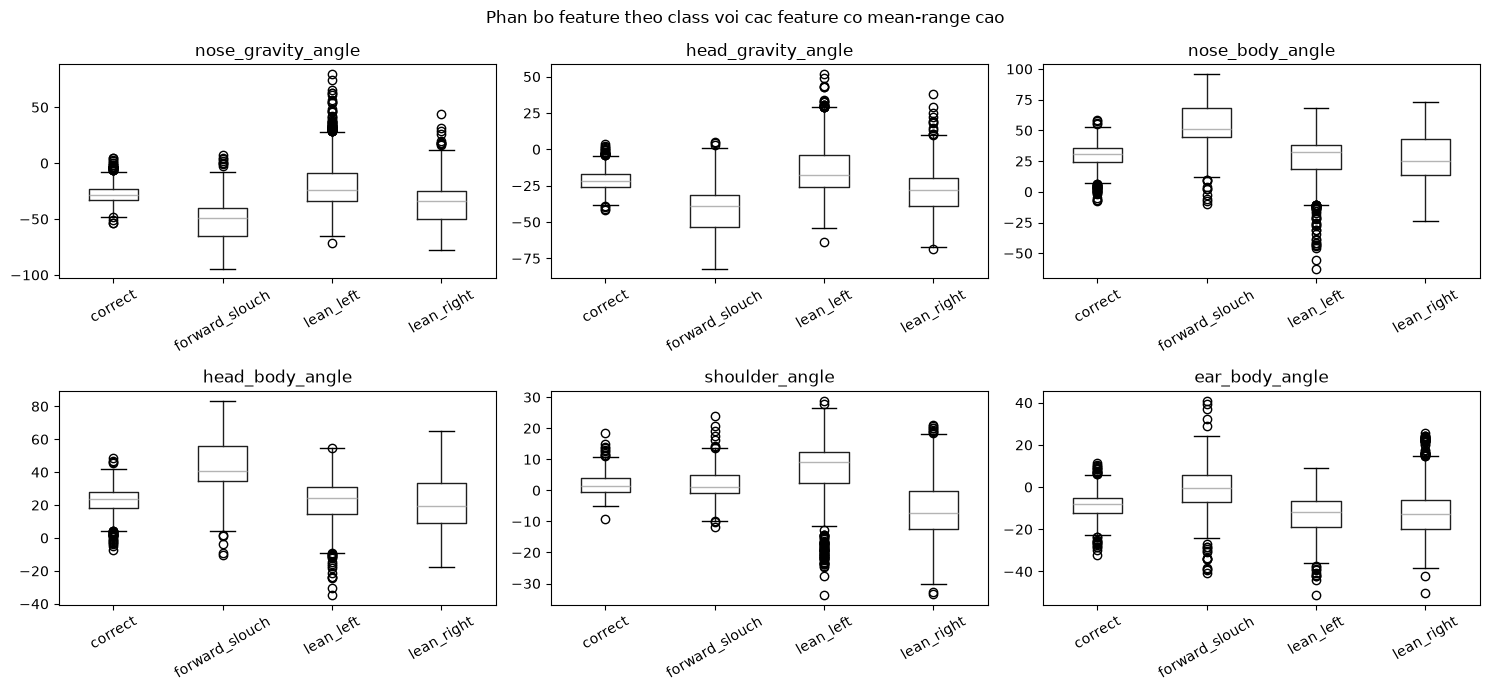

In [14]:
class_means = df.groupby("label")[feature_cols].mean().reindex(EXPECTED_LABELS)
mean_range = (class_means.max(axis=0) - class_means.min(axis=0)).sort_values(ascending=False)
print("Top 12 features theo do chenh mean giua cac class:")
print(mean_range.head(12).to_string(float_format=lambda x: f"{x:.4f}"))

sep_features = mean_range.head(6).index.to_list()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
for ax, feature in zip(axes, sep_features):
    df.boxplot(column=feature, by="label", ax=ax, grid=False, rot=30)
    ax.set_title(feature)
    ax.set_xlabel("")
fig.suptitle("Phan bo feature theo class voi cac feature co mean-range cao")
plt.tight_layout()
plt.show()


**Nhan xet separability.** Mot so feature co khac biet mean/boxplot giua cac class, cho thay muc do phan tach nhat dinh tren dataset hien tai. Day la tin hieu de baseline model khai thac, nhung can danh gia bang train/test hoac cross-validation theo `person_id` de tranh lac quan do subject overlap.


## 13. Variation giua cac subject

Vi training sau nay du kien dung group-based split theo `person_id`, notebook kiem tra variation giua subject tren cung feature. Variation lon co the anh huong kha nang generalization sang nguoi chua thay.


Top 12 features theo spread mean giua cac person:
nose_body_angle           38.8144
nose_gravity_angle        36.0543
head_body_angle           29.9746
head_gravity_angle        27.2144
face_pitch_angle          26.2170
ear_body_angle            13.7089
head_axis_angle_spread    12.9696
eye_shoulder_angle        10.5147
shoulder_angle             8.5583
nose_shoulder_asymmetry    0.4320
nose_y_body                0.3800
eye_shoulder_asymmetry     0.3636


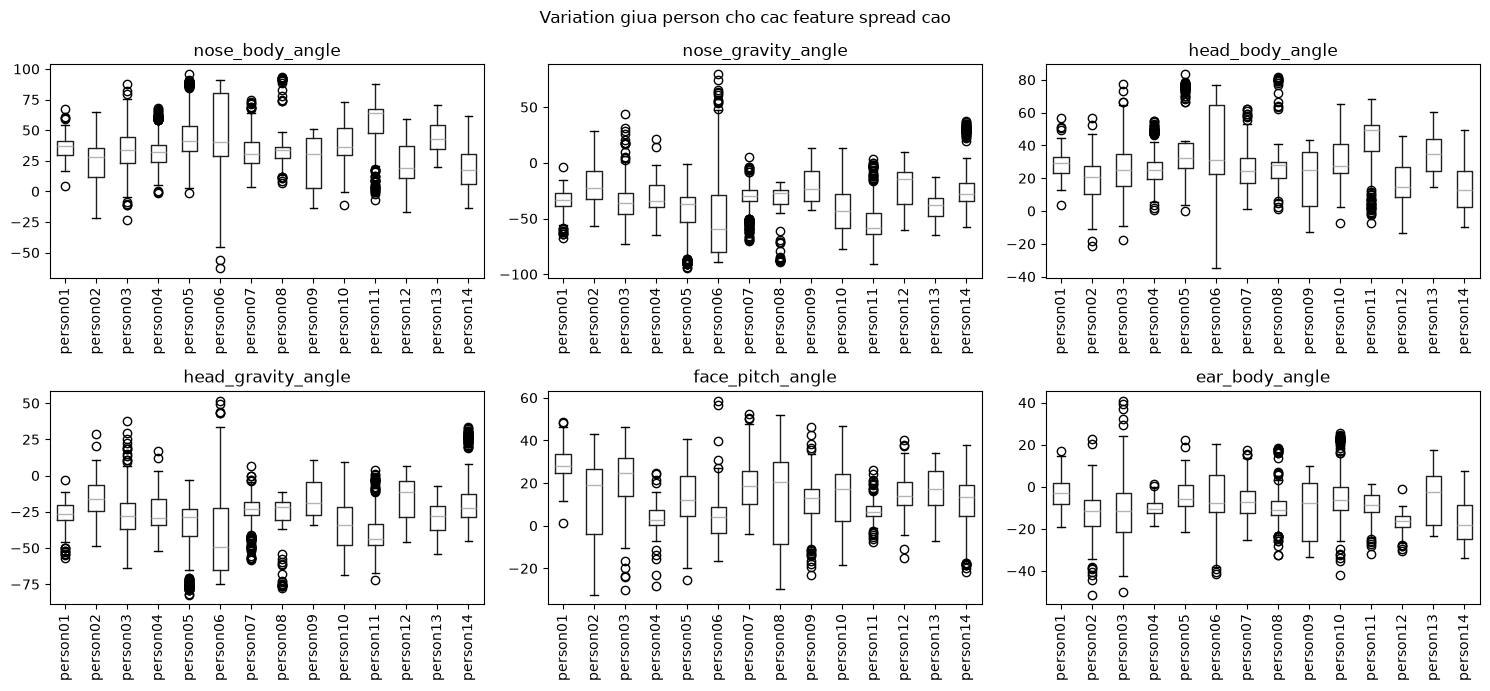

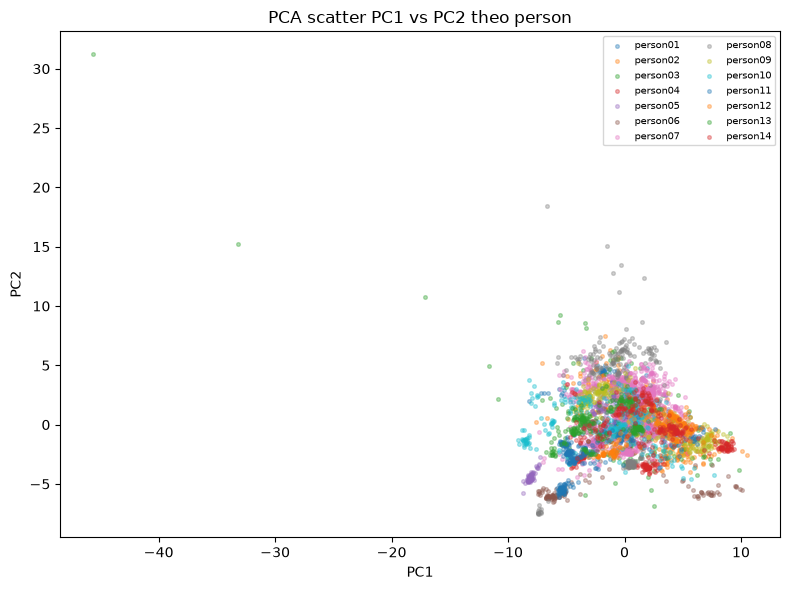

In [15]:
person_feature_means = df.groupby("person_id")[feature_cols].mean()
subject_spread = (person_feature_means.max(axis=0) - person_feature_means.min(axis=0)).sort_values(ascending=False)
print("Top 12 features theo spread mean giua cac person:")
print(subject_spread.head(12).to_string(float_format=lambda x: f"{x:.4f}"))

subject_features = subject_spread.head(6).index.to_list()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
for ax, feature in zip(axes, subject_features):
    df.boxplot(column=feature, by="person_id", ax=ax, grid=False, rot=90)
    ax.set_title(feature)
    ax.set_xlabel("")
fig.suptitle("Variation giua person cho cac feature spread cao")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for person_id, sub in pca_plot_df.groupby("person_id"):
    ax.scatter(sub["PC1"], sub["PC2"], s=7, alpha=0.35, label=person_id)
ax.set_title("PCA scatter PC1 vs PC2 theo person")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


**Nhan xet subject variation.** Mot so feature co spread mean giua person dang chu y; feature spread lon nhat la `nose_body_angle`. Dieu nay cung co nhu cau danh gia bang group split theo `person_id`. Variation giua subject la van de khac voi class imbalance va khong nen xu ly bang cach loai `person05`.


## 14. Kiem tra nguy co data leakage

Notebook nay chi exploration: khong luu scaler, khong luu PCA artifact, khong tao train/test split cuoi cung, va khong dua metadata vao numeric feature/PCA. Moi preprocessing chinh thuc can duoc fit rieng trong training pipeline sau khi split.


In [16]:
leakage_checks = {
    "metadata_co_nam_trong_feature_cols": bool(set(METADATA_COLS) & set(feature_cols)),
    "session_key_co_nam_trong_feature_cols": "session_key" in feature_cols,
    "label_co_nam_trong_feature_cols": "label" in feature_cols,
    "so_feature": len(feature_cols),
    "so_cot_dau_vao_pca": len(feature_cols),
}
print("Kiem tra nguy co dua metadata vao feature:")
print(pd.Series(leakage_checks).to_string())
if leakage_checks["metadata_co_nam_trong_feature_cols"] or leakage_checks["session_key_co_nam_trong_feature_cols"] or leakage_checks["label_co_nam_trong_feature_cols"]:
    raise ValueError("Phat hien metadata leakage trong feature columns")


Kiem tra nguy co dua metadata vao feature:
metadata_co_nam_trong_feature_cols       False
session_key_co_nam_trong_feature_cols    False
label_co_nam_trong_feature_cols          False
so_feature                                  29
so_cot_dau_vao_pca                          29


## 15. Ket luan cuoi notebook

1. Dataset hien tai co `4014` valid samples, `14` persons, `16` person-session combinations va `4` classes.
2. Class distribution tuong doi on: `{'correct': 1051, 'forward_slouch': 889, 'lean_left': 1054, 'lean_right': 1020}`. Class thap nhat la `forward_slouch` (`889` samples), nhung ty le max/min khoang `1.19x`, chua phai mat can bang nghiem trong.
3. Sample distribution giua person co chenh lech ro hon class distribution. `person07` co `796` samples do co 3 sessions; cac person con lai co 1 session theo du lieu hien tai.
4. Khong phat hien duplicate rows, missing values, NaN hoac Inf trong feature matrix.
5. Feature distributions co outlier theo IQR o mot so feature; notebook chi thong ke, khong xoa/cap sample.
6. Correlation analysis cho thay `22` feature pairs co `abs_corr >= 0.90`, goi y mot so redundancy co the can theo doi.
7. PCA tren 29 scaled features can `4` components de dat >=90% variance va `6` components de dat >=95% variance; metadata khong duoc dua vao PCA.
8. Subject-to-subject variation dang chu y o mot so feature, vi vay group-based split theo `person_id` la can thiet khi danh gia baseline.
9. Dataset du dieu kien chuyen sang preprocessing/train baseline V02, voi luu y phai xu ly scaling/outlier/correlation trong pipeline training dung cach.
10. Cac van de preprocessing nen xem xet sau nay: chuan hoa feature trong pipeline sau split, xu ly outlier robust, kiem tra redundancy/correlation, va danh gia bang group split de do generalization sang person chua thay.

Notebook nay khong ket luan model tot/xau vi chua train model.
